In [115]:
from IPython.display import Audio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path
import pandas as pd
import numpy as np
import librosa
import librosa.display
import wave

MFCC of fourier

Mel-Frequency Cepstral Coefficients

MLP model avec tensorflow

In [116]:
plt.figure(figsize=(12,4))
test_file_path: Path = Path('../input_data/id00/normal/id_00_n_00000004.wav')
data, sample_rate = librosa.load(test_file_path)
Audio(data=data, rate=sample_rate)

<Figure size 1200x400 with 0 Axes>

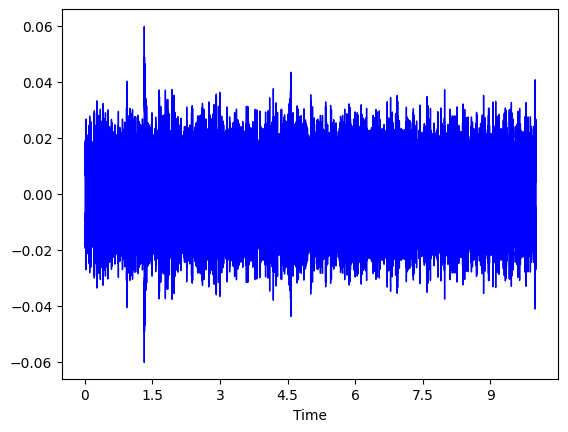

In [117]:
_ = librosa.display.waveshow(data, sr=sample_rate, color='blue')

In [118]:
def build_dataFrame(folder: Path, columns: list[str] = ["file", "label_name"], accepted_files: list[str] = [".wav"]) -> pd.DataFrame:
    df: pd.DataFrame = pd.DataFrame(columns=columns)
    for child in folder.iterdir():
        if child.is_dir():
            df = pd.concat([df, build_dataFrame(child, columns, accepted_files)], ignore_index=True)
        elif child.suffix in accepted_files:
            df = pd.concat([df, pd.DataFrame([[str(child), folder.name]], columns=columns)])

    return df


df: pd.DataFrame = build_dataFrame(Path('../input_data'))
df['label'] = (df['label_name'] == 'normal').astype(int)
df

,file,label_name,label
0,..\input_data\id00\abnormal\id_00_a_00000000.wav,abnormal,0
1,..\input_data\id00\abnormal\id_00_a_00000001.wav,abnormal,0
2,..\input_data\id00\abnormal\id_00_a_00000002.wav,abnormal,0
3,..\input_data\id00\abnormal\id_00_a_00000003.wav,abnormal,0
4,..\input_data\id00\abnormal\id_00_a_00000004.wav,abnormal,0
...,...,...,...
4166,..\input_data\id06\normal\id_06_n_00001031.wav,normal,1
4167,..\input_data\id06\normal\id_06_n_00001032.wav,normal,1
4168,..\input_data\id06\normal\id_06_n_00001033.wav,normal,1
4169,..\input_data\id06\normal\id_06_n_00001034.wav,normal,1


<Axes: title={'center': 'Count for each label'}, xlabel='label', ylabel='count'>

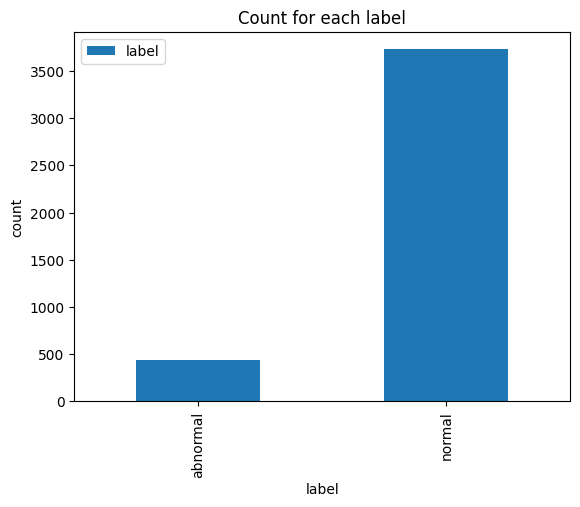

In [119]:
df.groupby("label_name").count().plot(kind="bar", y="label", title="Count for each label", xlabel="label", ylabel="count")

In [120]:
def compute_mfcc(file_path: Path, n_mfcc: int = 128) -> np.array:
    data, sample_rate = librosa.load(file_path)
    mfcc = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=n_mfcc)
    return np.mean(mfcc.T, axis = 0)

compute_mfcc(test_file_path)

array([-3.5473883e+02,  1.6419548e+02, -5.2497906e+01,  5.0676464e+01,
       -4.4394897e+01,  3.7328239e+01, -2.6444733e+01,  2.2815985e+01,
       -1.5366374e+01,  4.5237913e+00,  4.5431274e-01,  3.9114902e+00,
        1.4891262e+01, -7.5458713e+00,  1.0261470e+01, -1.7613497e+01,
        6.3236771e+00, -1.1680189e+01,  7.6896753e+00, -5.0634155e+00,
       -4.9656744e+00, -5.4269180e+00, -7.6687098e+00,  5.6480422e+00,
       -6.0491395e+00,  5.6881289e+00, -8.1761656e+00,  3.1305869e+00,
       -5.3246536e+00,  7.6088729e+00,  7.2656860e+00,  2.1833196e+00,
       -4.9070182e+00, -1.1502207e+01, -1.3313619e+00, -5.3512964e+00,
        7.7484479e+00, -8.3240044e-01,  3.6316726e+00, -2.7728982e+00,
        4.5044346e+00,  3.3713031e+00, -2.4341366e-01, -1.3387445e-02,
       -5.0026050e+00,  2.7175207e+00, -2.7819490e+00,  6.9107056e+00,
        2.8471565e+00,  5.4866838e+00, -2.0981472e+00, -3.8181810e+00,
       -4.6531167e+00, -6.6325498e+00, -2.3604434e+00, -5.1231561e+00,
      

In [121]:
data, sample_rate = librosa.load(test_file_path)
S = librosa.feature.melspectrogram(y=data, sr=sample_rate, n_mels=128, fmax=8000)
librosa.feature.mfcc(S=librosa.power_to_db(S))

array([[-3.31970490e+02, -3.09855011e+02, -3.12597076e+02, ...,
        -3.07726440e+02, -2.97580139e+02, -2.88376953e+02],
       [ 1.01303452e+02,  1.03878357e+02,  1.03500336e+02, ...,
         1.08910858e+02,  1.08629349e+02,  1.11622894e+02],
       [ 3.33363271e+00, -1.21627688e+00, -9.18472481e+00, ...,
        -5.18169928e+00, -1.33245869e+01, -1.84115944e+01],
       ...,
       [ 6.67074394e+00,  7.04600954e+00,  5.44039917e+00, ...,
         2.16988873e+00,  7.24516630e+00,  8.40003586e+00],
       [-8.25926971e+00, -1.35843697e+01, -1.20151157e+01, ...,
        -6.96679974e+00, -7.32648373e+00, -8.68620968e+00],
       [-1.24127140e+01, -1.41487312e+01, -6.78754139e+00, ...,
         4.52729344e-01,  1.00630522e-01,  3.15683794e+00]], dtype=float32)

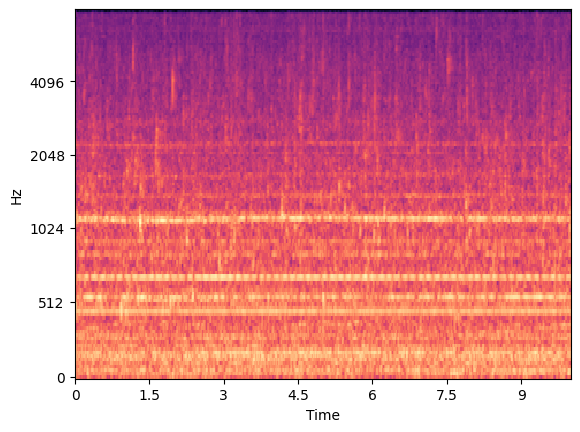

In [122]:
librosa.display.specshow(librosa.power_to_db(S, ref=np.max), x_axis='time', y_axis='mel', fmax=8000)

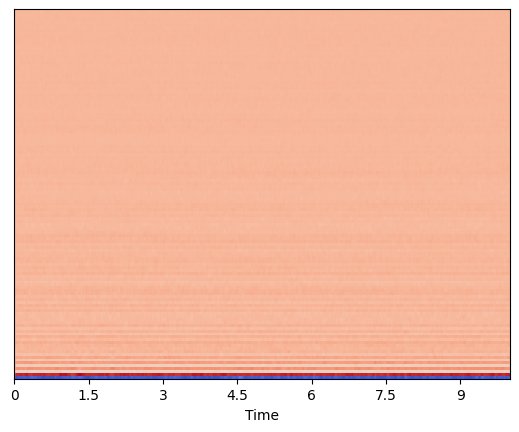

In [123]:
data, sample_rate = librosa.load(test_file_path)
test_mfcc = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=128)
librosa.display.specshow(test_mfcc, sr=sample_rate, x_axis='time')

In [124]:
model_df: pd.DataFrame = df[df['label_name'] == 'abnormal']
model_df = pd.concat([model_df, df[df['label_name'] == 'normal'].sample(len(model_df))])
model_df

,file,label_name,label
0,..\input_data\id00\abnormal\id_00_a_00000000.wav,abnormal,0
1,..\input_data\id00\abnormal\id_00_a_00000001.wav,abnormal,0
2,..\input_data\id00\abnormal\id_00_a_00000002.wav,abnormal,0
3,..\input_data\id00\abnormal\id_00_a_00000003.wav,abnormal,0
4,..\input_data\id00\abnormal\id_00_a_00000004.wav,abnormal,0
...,...,...,...
949,..\input_data\id00\normal\id_00_n_00000816.wav,normal,1
473,..\input_data\id00\normal\id_00_n_00000337.wav,normal,1
2677,..\input_data\id04\normal\id_04_n_00000333.wav,normal,1
2521,..\input_data\id04\normal\id_04_n_00000177.wav,normal,1


In [125]:
featuresdf: pd.DataFrame = model_df.apply(lambda x: compute_mfcc(Path(x['file']), n_mfcc=128), axis=1, result_type="expand")
featuresdf

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,-321.222992,161.563461,-46.206860,55.168354,-30.069130,35.404831,-18.946020,18.393908,-12.086336,3.400769,...,0.145607,-0.039852,0.618202,-0.587062,0.343121,0.082845,0.542172,0.400031,0.089329,-0.490856
1,-320.977417,167.908432,-44.368900,40.677513,-42.106266,19.147713,-25.312412,13.552672,-17.638550,-0.264216,...,0.856628,0.769613,0.933692,0.116763,0.690788,-0.074645,0.077221,-0.165525,0.375114,0.285212
2,-324.376801,160.314636,-51.098068,55.774914,-33.495483,41.504848,-17.362972,23.280289,-14.025704,2.838785,...,0.362352,-0.074128,1.103146,-0.150856,1.047235,0.014511,0.483503,0.109503,0.239052,-0.180067
3,-317.290100,177.566086,-43.040440,46.352135,-33.901649,22.879473,-16.774864,13.088657,-14.463815,0.296685,...,-0.018614,-0.175538,0.432689,0.077000,0.533830,0.102704,-0.351584,0.162695,-0.113034,0.260952
4,-318.168152,163.605453,-40.252167,51.010990,-27.869959,28.010178,-16.415575,15.660224,-11.460465,2.919983,...,-0.112639,-0.199484,0.338437,-0.463428,-0.178110,-0.277402,-0.166622,0.166162,-0.148594,0.135906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949,-359.175354,163.913162,-43.699509,51.984695,-44.776520,39.382717,-25.554909,25.778093,-9.915807,8.407314,...,1.497173,0.334649,0.596895,-1.120313,-0.102892,-0.845264,0.763536,-1.228439,0.307948,-0.279379
473,-381.602234,165.656052,-38.474434,58.090767,-28.282166,42.463833,-9.250911,20.963167,-7.821505,2.322738,...,0.593417,0.279364,0.721079,-0.360271,0.259455,0.149941,0.213807,0.293369,0.072765,0.541554
2677,-342.219879,163.630875,-52.966740,69.996071,-35.966007,44.712311,-33.335125,27.620110,-12.362830,4.397701,...,2.578633,-0.301714,-0.901285,-0.688776,1.853884,-2.192275,0.381223,2.263596,0.038508,-3.845485
2521,-374.404144,154.387955,-30.899759,74.804214,-25.214327,38.339146,-26.916899,23.838348,-8.025849,7.611905,...,2.084224,0.421689,0.225782,0.551483,2.718438,-1.592755,-1.005481,0.650301,0.602701,-2.384470


In [126]:
X_train, X_test, y_train, y_test = train_test_split(featuresdf, model_df, test_size=0.20, random_state=42)
# Pytorch / Keras

In [127]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 64, 32, 16), max_iter=1000, random_state=1, solver='adam', activation="relu")
mlp.fit(X_train, y_train['label'])
y_pred = mlp.predict(X_test)

print(f"Accuracy score: {accuracy_score(y_test['label'], y_pred)}")
print(f"Classification report:\n{classification_report(y_test['label'], y_pred)}")

Accuracy score: 0.8820224719101124
Classification report:
              precision    recall  f1-score   support

           0       0.95      0.81      0.88        91
           1       0.83      0.95      0.89        87

    accuracy                           0.88       178
   macro avg       0.89      0.88      0.88       178
weighted avg       0.89      0.88      0.88       178



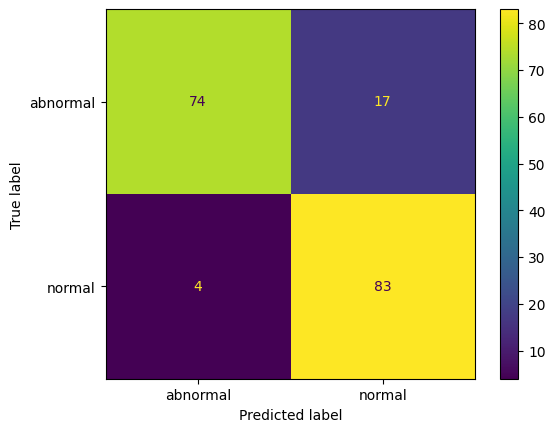

In [128]:
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test['label'], y_pred), display_labels=['abnormal', 'normal']).plot()

In [129]:
# Implementation avec keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(128,)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpointer = ModelCheckpoint(filepath='./saved_models/weights.best.basic_mlp.keras', verbose=1, save_best_only=True)

mod = model.fit(X_train, y_train['label'], epochs=100, batch_size=32, validation_split=0.10, callbacks=[checkpointer], verbose=1)

Epoch 1/100
 1/20 [>.............................] - ETA: 9s - loss: 15.4726 - accuracy: 0.4375
Epoch 1: val_loss improved from inf to 1.73956, saving model to ./saved_models\weights.best.basic_mlp.keras
20/20 [==============================] - 1s 6ms/step - loss: 10.3833 - accuracy: 0.5086 - val_loss: 1.7396 - val_accuracy: 0.5211
Epoch 2/100
 1/20 [>.............................] - ETA: 0s - loss: 6.8166 - accuracy: 0.4688
Epoch 2: val_loss improved from 1.73956 to 1.01424, saving model to ./saved_models\weights.best.basic_mlp.keras
20/20 [==============================] - 0s 2ms/step - loss: 6.0644 - accuracy: 0.5086 - val_loss: 1.0142 - val_accuracy: 0.5493
Epoch 3/100
 1/20 [>.............................] - ETA: 0s - loss: 4.1098 - accuracy: 0.5625
Epoch 3: val_loss improved from 1.01424 to 0.77681, saving model to ./saved_models\weights.best.basic_mlp.keras
20/20 [==============================] - 0s 3ms/step - loss: 3.7042 - accuracy: 0.5368 - val_loss: 0.7768 - val_accuracy: 0

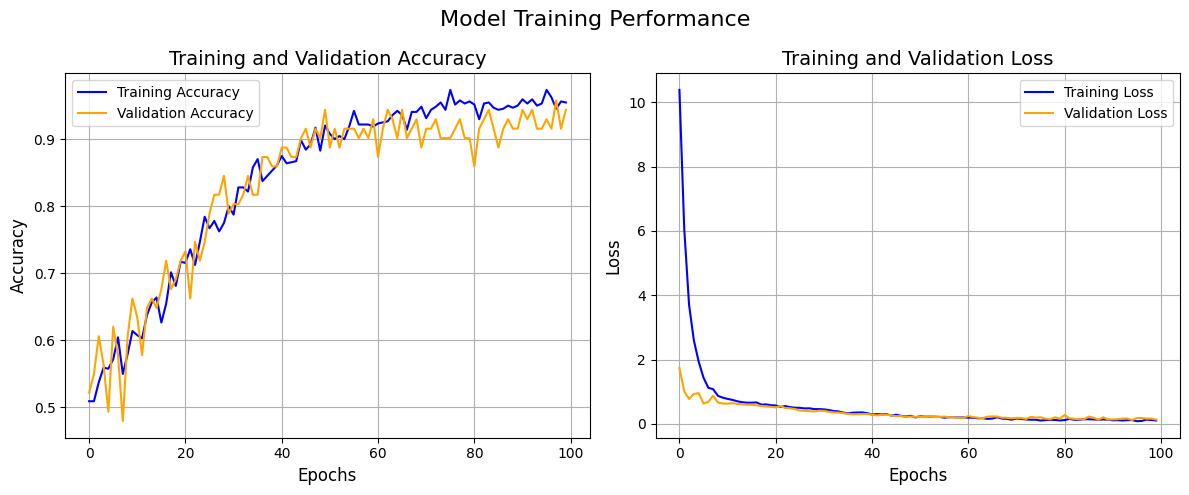

In [130]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()

In [131]:
model.test_on_batch(X_test, y=y_test['label'], return_dict=True)

{'loss': 0.20875628292560577, 'accuracy': 0.915730357170105}